In [1]:
import pandas as pd
from mobgap.data import GenericMobilisedDataset
from mobgap.pipeline import MobilisedPipelineHealthy

C:\Users\ac4jmi\PycharmProjects\mobilise-d_mobgap_tutorial\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ac4jmi\PycharmProjects\mobilise-d_mobgap_tutorial\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\ac4jmi\PycharmProjects\mobilise-d_mobgap_tutorial\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own

In [2]:
import os
def get_paths_with_extension(extension):
    paths = []
    dataset_folder = os.path.join(os.getcwd())

    for root, dirs, files in os.walk(dataset_folder):
        for file in files:
            if file.lower().endswith(extension):
                path = os.path.join(root, file)
                if not ".venv" in path:
                    paths.append(path)
    
    return paths

cwa_files = get_paths_with_extension(".cwa")

print("Here is the list of all our \".cwa\" files:")
print(cwa_files)

Here is the list of all our ".cwa" files:
['C:\\Users\\ac4jmi\\PycharmProjects\\mobilise-d_mobgap_tutorial\\6032032_0000000000.cwa']


In [3]:
from functions import *
if len(cwa_files) > 1:
    print("Error, more than 1 \".cwa\" file in your folder, make sure you just have your file from today in there!")
else:
    samples = get_cwa_data(cwa_files[0], resample = True, prints = 0)
# note that we use display to make things look nice in JuPyter, rather than print. 
# If you want to see why, try replacing the following "display" with "print"...
display(samples.head(10))

,timestamp,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z
0,2025-08-07 11:11:45.316430080,-0.347900,1.341309,0.771973,-42.480469,70.373535,42.419434
1,2025-08-07 11:11:45.326430208,-0.504392,1.531250,0.746826,-28.442297,92.346234,15.807106
2,2025-08-07 11:11:45.336430080,-0.416748,1.536377,0.740479,-24.841309,94.116211,-26.123047
3,2025-08-07 11:11:45.346429952,-0.280029,1.444580,0.727539,-13.671875,103.454590,-53.283691
4,2025-08-07 11:11:45.356430080,-0.225098,1.335205,0.615479,-2.807617,115.905762,-63.842773
5,2025-08-07 11:11:45.366429952,-0.092773,1.137939,0.486816,0.061035,115.661621,-63.354492
6,2025-08-07 11:11:45.376430080,0.011230,0.987305,0.354736,3.784180,112.609863,-45.166016
7,2025-08-07 11:11:45.386429952,0.008789,0.889648,0.230957,3.845215,103.576660,-16.418457
8,2025-08-07 11:11:45.396430080,0.020264,0.832520,0.074707,9.704590,93.688965,10.314941
9,2025-08-07 11:11:45.406429952,0.052979,0.833252,-0.035645,29.724121,81.542969,36.010742


<Axes: >

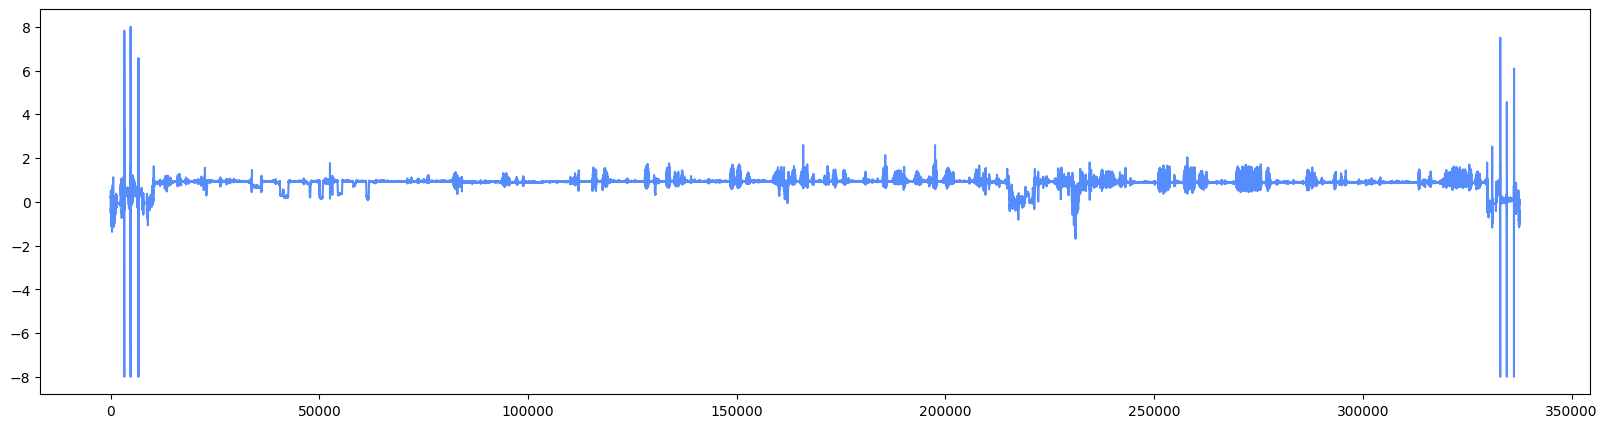

In [4]:
samples["accel_x"].plot(figsize = (20, 5)) # note that figsize contains the x and y sizes for the figure. Have a play with these to see what happens.

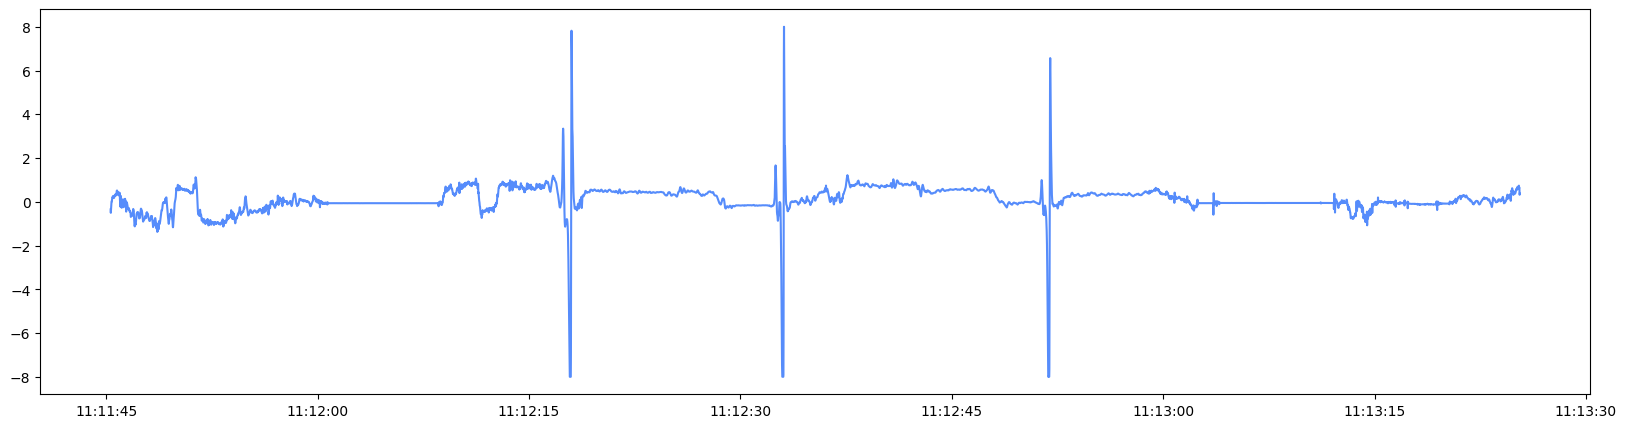

In [6]:
import matplotlib.pyplot as plt    # we'll use matplotlib for this plot

start_id = 0    # the first point we want to plot - feel free to change
end_id = 10000   # the last point we want to plot - feel free to change

samples_to_plot = samples.iloc[start_id:end_id] # here we make a copy of our table, but use iloc to get just the values from the start_id to the end_id

plt.figure(figsize=(20, 5))                                   # first, we tell matplotlib how big the figure will be.
plt.plot(samples_to_plot["timestamp"], samples_to_plot["accel_x"]) # next, we plot the x and y axes as columns from our table
plt.show()                                                    # finally, we show the figure

In [7]:
reformatted_time = samples["timestamp"].astype('int64') // 10**9  # convert nanoseconds to seconds
reformatted_time = reformatted_time.values.reshape(-1, 1).astype(float)

display(reformatted_time)
print(reformatted_time)

array([[1.75456510e+09],
       [1.75456510e+09],
       [1.75456510e+09],
       ...,
       [1.75456848e+09],
       [1.75456848e+09],
       [1.75456848e+09]], shape=(337595, 1))

[[1.75456510e+09]
 [1.75456510e+09]
 [1.75456510e+09]
 ...
 [1.75456848e+09]
 [1.75456848e+09]
 [1.75456848e+09]]


In [8]:
start_date_time = samples["timestamp"].iloc[0].strftime('%d-%b-%Y %H:%M:%S')
print(start_date_time)

07-Aug-2025 11:11:45


In [9]:
fs = 100#len(samples)/(reformatted_time[-1][0] - reformatted_time[0][0])
print(fs)

100


In [10]:
data = {
    "TimeMeasure1": {
        "Test1": {
            "Trial1": {
                "SU": {
                    "LowerBack": {
                        "Fs": {
                            "Acc": fs,
                            "Gyr": fs
                        },
                        "Acc": samples[["accel_x", "accel_y", "accel_z"]].values.astype(float),
                        "Gyr": samples[["gyro_x", "gyro_y", "gyro_z"]].values.astype(float),
                        "Timestamp": reformatted_time
                    }
                }, 
                "StartDateTime": start_date_time,
                "TimeZone": "Europe/UK"
            }
        }
    }
}

data = {"data": data}

In [11]:
gender = "M"
handedness = "R"
age = 26
weight = 80.4
height = 183
sensor_height = 111

infoForAlgo = {
    "TimeMeasure1": {
        "Subject_ID": "1",
        "Cohort": "HA",
        "Gender": gender,
        "Handedness": handedness,
        "Age": age,
        "Weight": weight,
        "Height": height,
        "SensorHeight": sensor_height,
        "WalkingAid_01": 0,
        "WalkingAid_Side": "",
        "WalkingAid_Description": "",
        "SensorType_SU": "AX6",
        "SensorAttachment_SU": "Body-Worn"
    }
}

infoForAlgo = {"infoForAlgo": infoForAlgo}

In [12]:
current_dir = os.getcwd()                                   # get current working directory (cwd)
target_dir = os.path.join(current_dir, r'Dataset/HA/1')     # define the target directory relative to the current directory
if not os.path.exists(target_dir):                          # check if the folders already exist
   os.makedirs(target_dir)                                  # if they dont, make the folders

In [13]:
from scipy.io import savemat

savemat(target_dir + "\\infoForAlgo.mat", infoForAlgo, do_compression=False)
savemat(target_dir + "\\data.mat", data, do_compression=False)

In [14]:
mat_files = get_paths_with_extension(".mat")
mat_files = [file for file in mat_files if file.endswith("data.mat")]
print(mat_files)
dataset = GenericMobilisedDataset(
    paths_list = mat_files,
    test_level_names = ["TimeMeasure", "Test", "Trial"], # This is the structure (without numbers) of the data inside the data.mat struct.
    measurement_condition = "laboratory",
    parent_folders_as_metadata=["dataset", "cohort", "subject"] # these are the column headings for the metadata, the columns get populated with the folder names.
)

print(dataset)

['C:\\Users\\ac4jmi\\PycharmProjects\\mobilise-d_mobgap_tutorial\\Dataset\\HA\\1\\data.mat']
GenericMobilisedDataset [1 groups/rows]

      dataset cohort subject   TimeMeasure   Test   Trial
   0  Dataset     HA       1  TimeMeasure1  Test1  Trial1


C:\Users\ac4jmi\PycharmProjects\mobilise-d_mobgap_tutorial\.venv\Lib\site-packages\mobgap\data\_mobilised_matlab_loader.py:1245: UserWarning: Global caching is a little tricky to get right and our implementation is not yet battle-tested. Please double check that the results are correct and report any issues you find.
  return hybrid_cache(self.memory, 1)(_load_test_data_without_checks)(


In [15]:
pipeline = MobilisedPipelineHealthy()
pipeline = pipeline.safe_run(dataset)
print("Pipeline finished running!")

Pipeline finished running!


In [16]:
display(pipeline.aggregated_parameters_) # all parameters across all walking bouts

,wb_all__count,total_walking_duration_min,wb_all__n_raw_initial_contacts__sum,wb_all__duration_s__avg,wb_all__duration_s__p90,wb_all__duration_s__var,wb_all__cadence_spm__avg,wb_all__stride_duration_s__avg,wb_all__cadence_spm__var,wb_all__stride_duration_s__var,...,wb_30__count,wb_30__walking_speed_mps__avg,wb_30__stride_length_m__avg,wb_30__cadence_spm__avg,wb_30__stride_duration_s__avg,wb_30__walking_speed_mps__p90,wb_30__cadence_spm__p90,wb_30__walking_speed_mps__var,wb_30__stride_length_m__var,wb_60__count
all_wbs,50,10.154833,924,9.36,21.489,0.791491,83.54947,1.310787,0.125647,0.151585,...,1,1.172928,1.389173,101.028626,1.185192,1.172928,101.028626,NaN,NaN,1


In [17]:
display(pipeline.per_wb_parameters_.head(5))     # first 5 per-walking-bout parameters

,start,end,n_strides,rule_name,rule_obj,duration_s,n_raw_initial_contacts,stride_duration_s,cadence_spm,stride_length_m,walking_speed_mps
wb_id,,,,,,,,,,,
0,5352,6032,6,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",6.80,9,1.416667,57.618512,0.743266,0.372978
1,93725,95012,15,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",12.87,17,1.484667,67.972748,0.837550,0.485143
2,98622,99115,6,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",4.93,8,1.351667,75.285032,0.457078,0.273297
3,110895,111418,4,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",5.23,6,1.857500,65.261935,0.701169,0.382793
4,115502,116298,10,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",7.96,12,1.190000,86.087475,1.186048,0.866639


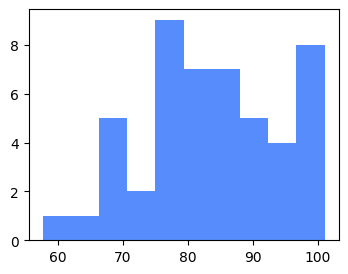

In [18]:
plt.figure(figsize = (4, 3))
plt.hist(pipeline.per_wb_parameters_["cadence_spm"], bins = 10)
plt.show()